In [9]:
import sys
from pathlib import Path

ML_ROOT = Path.cwd().parent

if str(ML_ROOT) not in sys.path:
    sys.path.append(str(ML_ROOT))

print(ML_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import wfdb
from collections import Counter

from src.datasets.heartbeat_extractor import extract_heartbeat
from src.datasets.record_processor import process_record

c:\Abhiram\Projects\ecg-cardiac-abnormality-detection\ml


In [10]:
record = wfdb.rdrecord("../data/raw/mitdb/100")
annotation = wfdb.rdann("../data/raw/mitdb/100", "atr")

signal = record.p_signal[:, 0]

In [11]:
VALID_LABELS = {
    "N",
    "V",
    "A",
    "L",
    "R",
}

In [12]:
X_record, y_record = process_record(
    signal=signal,
    annotation=annotation,
    valid_labels=VALID_LABELS,
)

In [13]:
print(X_record.shape)
print(y_record.shape)

(2271, 250)
(2271,)


In [14]:
distribution = Counter(y_record)

for label, count in distribution.items():
    print(f"{label}: {count}")

N: 2237
A: 33
V: 1


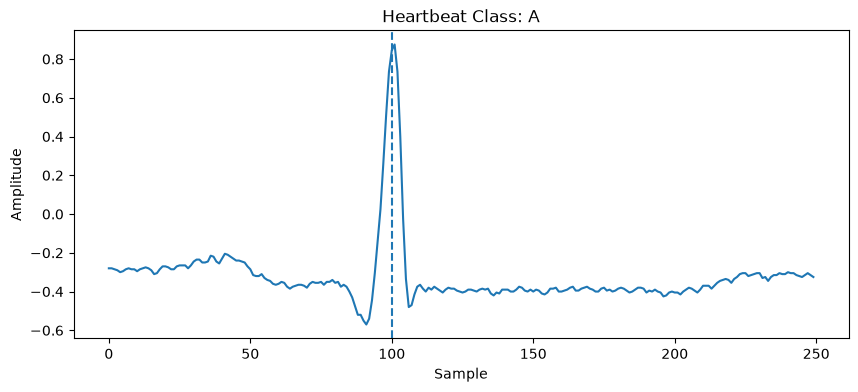

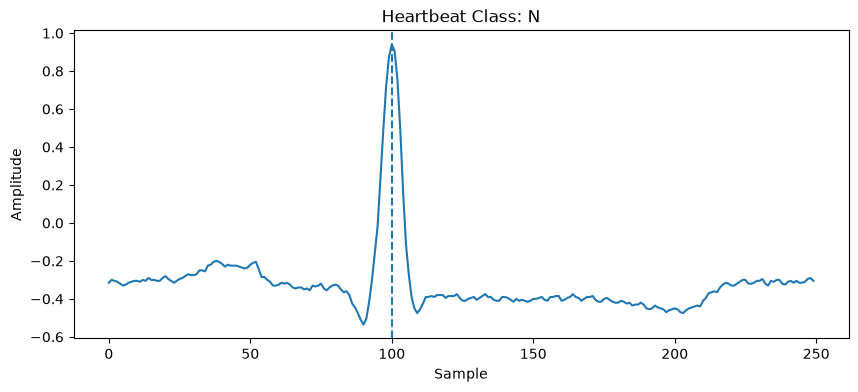

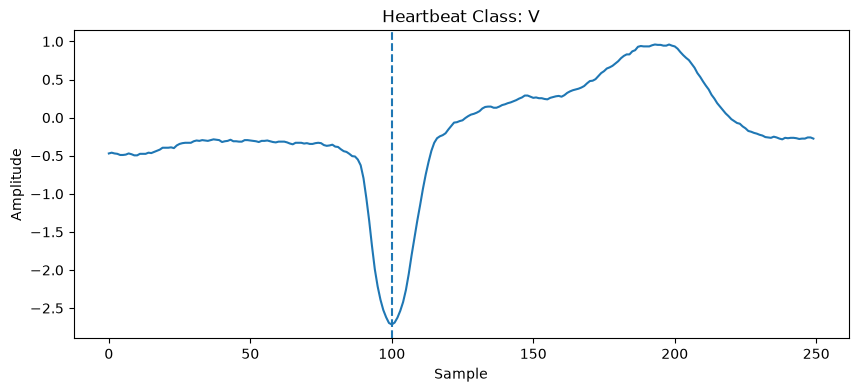

In [15]:
unique_labels = np.unique(y_record)

for label in unique_labels:
    index = np.where(y_record == label)[0][0]

    heartbeat = X_record[index]

    plt.figure(figsize=(10, 4))
    plt.plot(heartbeat)

    plt.axvline(
        x=100,
        linestyle="--"
    )

    plt.title(f"Heartbeat Class: {label}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.show()